# Linear Programming: Standard Form and Basic Solutions

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ahmed-Bayoumy/MECH559/blob/DEV/L07/L07_lp_formulation_and_basic_solutions.ipynb)
### MECH 559 - Systems Optimization - L07

Companion notebook to the first half of the "Linear programming" lecture: formulating a real LP, converting it to standard form with slack/surplus variables, and finding the optimum by brute-force enumeration of *basic solutions* - before we need anything as clever as the simplex method (that's the companion notebook, `L07_simplex_method.ipynb`).

## Learning objectives

By the end, students should be able to:

1. Formulate a linear program from a word problem and convert a max problem to the min convention used in the standard form.
2. Convert inequality constraints to equality constraints using slack and surplus variables, and verify the transformed problem has the same optimum.
3. Enumerate all basic solutions of an underdetermined linear system $\mathbf{Ax}=\mathbf{b}$, and classify each as feasible, infeasible, or degenerate.
4. Reproduce the farmer's-problem table of all six basic solutions from the lecture and identify the optimal basic *feasible* solution.
5. Explain, quantitatively, why brute-force enumeration of basic solutions does not scale - motivating the simplex method.

> **Classroom rhythm:** pause at each **Predict** prompt, collect answers, then run the next cell.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from itertools import combinations
from math import comb
from scipy.optimize import linprog

plt.rcParams.update({
    "font.size": 11,
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

COLORS = {"boundary": "#00798C", "optimum": "#D1495B", "accent": "#EDAE49", "infeasible": "#7B7B7B"}

print(f"NumPy {np.__version__}; SciPy available for cross-checks")

NumPy 2.5.0; SciPy available for cross-checks


---
## 1. The farmer's problem

A farmer allocates $x_1$ acres to corn and $x_2$ acres to oats. Profit is \$40/acre (corn) and \$30/acre (oats). The farmer has 240 acres of land and 320 labour hours; corn needs 2 h/acre to plant, oats 1 h/acre.

$$
\max_{x_1,x_2} f = 40x_1+30x_2 \quad\text{s.t.}\quad 2x_1+x_2\le320,\;\; x_1+x_2\le240,\;\; x_1,x_2\ge0
$$

We solve optimization problems by *minimizing*, so we flip the sign of the objective: $\min -40x_1-30x_2$.

> **Predict:** the feasible region is a quadrilateral with 4 corners. Before running the next cell, guess which corner maximizes profit - the one that uses the most land, the most labour, or something in between?

In [3]:
def f_max(x1, x2):
    return 40*x1 + 30*x2

# The four vertices of the feasible region (read off the two binding-constraint
# intersections plus the two axis intercepts)
vertices = {
    "(0,0)": (0, 0),
    "(0,240) -- land only": (0, 240),
    "(160,0) -- labour only": (160, 0),
    "(80,160) -- both binding": (80, 160),
}

rows = []
for label, (x1, x2) in vertices.items():
    labour, land = 2*x1 + x2, x1 + x2
    rows.append({
        "vertex": label, "x1": x1, "x2": x2,
        "labour = 2x1+x2": labour, "land = x1+x2": land,
        "f_max = 40x1+30x2": f_max(x1, x2), "f_min = -f_max": -f_max(x1, x2),
    })
df_vertices = pd.DataFrame(rows)
df_vertices

,vertex,x1,x2,labour = 2x1+x2,land = x1+x2,f_max = 40x1+30x2,f_min = -f_max
0,"(0,0)",0,0,0,0,0,0
1,"(0,240) -- land only",0,240,240,240,7200,-7200
2,"(160,0) -- labour only",160,0,320,160,6400,-6400
3,"(80,160) -- both binding",80,160,320,240,8000,-8000


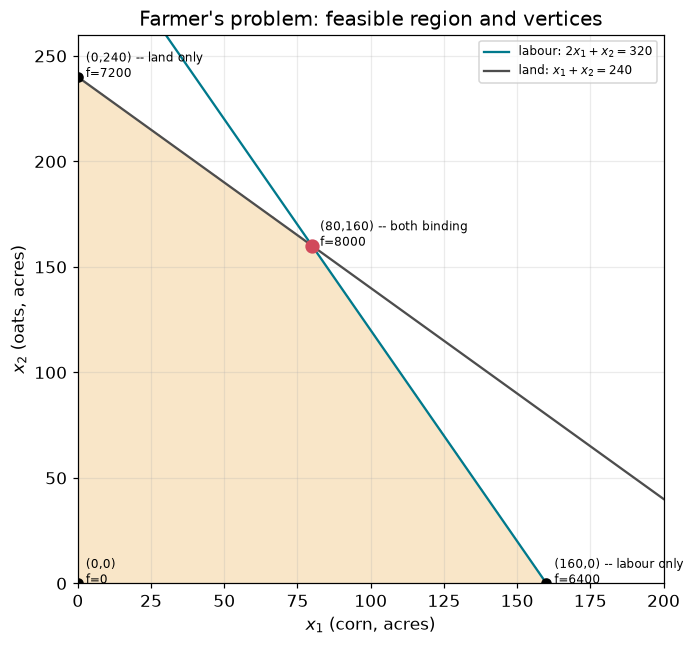

Optimal vertex: (80,160) -- both binding, f_max = 8000 (both constraints binding simultaneously - neither pure land- nor pure labour-limited)


In [4]:
fig, ax = plt.subplots(figsize=(6.5, 6))

x1g = np.linspace(0, 200, 400)
labour_line = 320 - 2*x1g
land_line = 240 - x1g

# Feasible region = intersection of both half-planes and the first quadrant
X1, X2 = np.meshgrid(np.linspace(0, 200, 400), np.linspace(0, 260, 400))
feasible = (2*X1 + X2 <= 320) & (X1 + X2 <= 240) & (X1 >= 0) & (X2 >= 0)
ax.contourf(X1, X2, feasible.astype(float), levels=[0.5, 1], colors=[COLORS["accent"]], alpha=0.3)

ax.plot(x1g, labour_line, color=COLORS["boundary"], label="labour: $2x_1+x_2=320$")
ax.plot(x1g, land_line, color="0.3", label="land: $x_1+x_2=240$")

for label, (x1, x2) in vertices.items():
    ax.scatter(x1, x2, color=COLORS["optimum"] if (x1, x2) == (80, 160) else "black", zorder=5,
               s=70 if (x1, x2) == (80, 160) else 35)
    ax.annotate(f"  {label}\n  f={f_max(x1,x2)}", (x1, x2), fontsize=8)

ax.set(xlim=(0, 200), ylim=(0, 260), xlabel="$x_1$ (corn, acres)", ylabel="$x_2$ (oats, acres)",
       title="Farmer's problem: feasible region and vertices")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

best = df_vertices.loc[df_vertices["f_max = 40x1+30x2"].idxmax()]
print(f"Optimal vertex: {best['vertex']}, f_max = {best['f_max = 40x1+30x2']:.0f} "
      f"(both constraints binding simultaneously - neither pure land- nor pure labour-limited)")

---
## 2. Standard form: slack and surplus variables

Every $\le$ constraint gets a **slack** variable ($+s\ge0$), every $\ge$ constraint gets a **surplus** variable ($-s\ge0$), turning inequalities into equalities:

$$
2x_1+x_2+s_1=320,\qquad x_1+x_2+s_2=240,\qquad x_1,x_2,s_1,s_2\ge0
$$

This does not change the optimum - it only changes how we *represent* it. Let's verify that numerically: solve the original inequality-constrained problem and the standard-form (equality-constrained) problem independently with `scipy.optimize.linprog` and confirm $x_1,x_2$ and the objective agree.

In [5]:
c = [-40, -30]

# --- Original form: inequality constraints ---
A_ub = [[2, 1], [1, 1]]
b_ub = [320, 240]
res_ineq = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=[(0, None), (0, None)], method="highs")

# --- Standard form: equality constraints with explicit slack columns ---
# variables ordered [x1, x2, s1, s2]
A_eq = [[2, 1, 1, 0], [1, 1, 0, 1]]
b_eq = [320, 240]
c_std = [-40, -30, 0, 0]
res_eq = linprog(c_std, A_eq=A_eq, b_eq=b_eq, bounds=[(0, None)]*4, method="highs")

print("Inequality form :  x* =", res_ineq.x, " f* =", res_ineq.fun)
print("Standard form    :  x* =", res_eq.x[:2], f"(s1={res_eq.x[2]:.1f}, s2={res_eq.x[3]:.1f})", " f* =", res_eq.fun)
assert np.allclose(res_ineq.x, res_eq.x[:2])
assert np.isclose(res_ineq.fun, res_eq.fun)
print("\nSame optimum, same objective - standard form is just a reformulation.")
print(f"At the optimum, s1={res_eq.x[2]:.1f} and s2={res_eq.x[3]:.1f}: both slacks are zero,")
print("confirming both the labour and land constraints are binding there, as seen in the plot above.")

Inequality form :  x* = [ 80. 160.]  f* = -8000.0
Standard form    :  x* = [ 80. 160.] (s1=0.0, s2=0.0)  f* = -8000.0

Same optimum, same objective - standard form is just a reformulation.
At the optimum, s1=0.0 and s2=0.0: both slacks are zero,
confirming both the labour and land constraints are binding there, as seen in the plot above.


---
## 3. Basic solutions of $\mathbf{Ax}=\mathbf{b}$

For $\mathbf{A}\in\mathbb{R}^{m\times n}$ with $n>m$ and full rank, picking any $m$ linearly independent columns as a *basis* $\mathbf{B}$ gives a **basic solution** $\hat{\mathbf x}=[\mathbf{x_B};\mathbf 0]$ with $\mathbf{x_B}=\mathbf{B}^{-1}\mathbf b$. It is **basic feasible** if $\mathbf{x_B}\ge\mathbf0$, and **degenerate** if some entry of $\mathbf{x_B}$ is exactly zero.

**Example 1 (from the lecture):** $\min x_1+x_2+x_3$ s.t. $x_1+2x_2+3x_3=4$. Here $m=1$, $n=3$, so there are $M=\binom{3}{1}=3$ possible bases.

> **Predict:** all three basic solutions here happen to be feasible. Which one do you expect minimizes $x_1+x_2+x_3$ - the one with the smallest coefficient in $\mathbf A$, or the largest?

In [6]:
def enumerate_basic_solutions(A, b, c, names=None, tol=1e-9):
    '''Enumerate every basic solution of Ax=b (A full row rank, n>m columns),
    tagging each as feasible/infeasible and degenerate/non-degenerate.'''
    A, b, c = np.asarray(A, float), np.asarray(b, float), np.asarray(c, float)
    m, n = A.shape
    names = names or [f"x{j+1}" for j in range(n)]
    rows = []
    for cols in combinations(range(n), m):
        B = A[:, cols]
        if abs(np.linalg.det(B)) < tol:
            continue  # singular basis, skip
        xB = np.linalg.solve(B, b)
        x = np.zeros(n)
        for i, col in enumerate(cols):
            x[col] = xB[i]
        rows.append({
            "basis": ", ".join(names[i] for i in cols),
            "x": np.round(x, 6),
            "objective": float(c @ x),
            "feasible": bool(np.all(xB >= -tol)),
            "degenerate": bool(np.any(np.abs(xB) < tol)),
        })
    return pd.DataFrame(rows)

A1, b1, c1 = [[1, 2, 3]], [4.0], [1, 1, 1]
df1 = enumerate_basic_solutions(A1, b1, c1, names=["x1", "x2", "x3"])
df1

,basis,x,objective,feasible,degenerate
0,x1,"[4.0, 0.0, 0.0]",4.000000,True,False
1,x2,"[0.0, 2.0, 0.0]",2.000000,True,False
2,x3,"[0.0, 0.0, 1.333333]",1.333333,True,False


In [7]:
feasible1 = df1[df1.feasible]
opt1 = feasible1.loc[feasible1.objective.idxmin()]
print(f"All {len(df1)} basic solutions are feasible and non-degenerate.")
print(f"Optimal basis: {{{opt1.basis}}}, x = {opt1.x}, objective = {opt1.objective:.4f}")
print("Matches the lecture: basing on x3 (largest coefficient in A) gives the smallest x3 needed,")
print("and since all coefficients in the objective are equal, that also gives the smallest objective.")

All 3 basic solutions are feasible and non-degenerate.
Optimal basis: {x3}, x = [0.       0.       1.333333], objective = 1.3333
Matches the lecture: basing on x3 (largest coefficient in A) gives the smallest x3 needed,
and since all coefficients in the objective are equal, that also gives the smallest objective.


---
## 4. The farmer's problem, revisited: all six basic solutions

In standard form the farmer's problem has $\mathbf A\in\mathbb R^{2\times4}$ (columns $x_1,x_2,s_1,s_2$), so $n=4$, $m=2$, and there are $M=\binom{4}{2}=6$ possible bases. Let's generate the *exact* table from the lecture programmatically, rather than by hand.

In [8]:
A = [[2, 1, 1, 0], [1, 1, 0, 1]]
b = [320, 240]
c = [-40, -30, 0, 0]
names = ["x1", "x2", "s1", "s2"]

df_farmer = enumerate_basic_solutions(A, b, c, names=names)
df_farmer = df_farmer.sort_values("objective").reset_index(drop=True)
df_farmer

,basis,x,objective,feasible,degenerate
0,"x1, s1","[240.0, 0.0, -160.0, 0.0]",-9600.0,False,False
1,"x2, s2","[0.0, 320.0, 0.0, -80.0]",-9600.0,False,False
2,"x1, x2","[80.0, 160.0, 0.0, 0.0]",-8000.0,True,False
3,"x2, s1","[0.0, 240.0, 80.0, 0.0]",-7200.0,True,False
4,"x1, s2","[160.0, 0.0, 0.0, 80.0]",-6400.0,True,False
5,"s1, s2","[0.0, 0.0, 320.0, 240.0]",0.0,True,False


In [9]:
feasible_only = df_farmer[df_farmer.feasible]
best = feasible_only.loc[feasible_only.objective.idxmin()]
print(f"M = C(4,2) = {comb(4,2)} bases in total, of which {feasible_only.shape[0]} are feasible.")
print(f"Optimal basic feasible solution: basis {{{best.basis}}}, x = {best.x}, objective = {best.objective:.0f}")
print("\nNote the two infeasible bases both have a MORE negative objective (-9600) than the true optimum")
print("(-8000) - a basic solution that ignores feasibility can look 'better' on paper while being useless.")

assert np.isclose(best.objective, -8000)
assert list(np.round(best.x)) == [80, 160, 0, 0]
print("\nMatches the graphical solution from Section 1: (x1,x2) = (80,160).")

M = C(4,2) = 6 bases in total, of which 4 are feasible.
Optimal basic feasible solution: basis {x1, x2}, x = [ 80. 160.   0.   0.], objective = -8000

Note the two infeasible bases both have a MORE negative objective (-9600) than the true optimum
(-8000) - a basic solution that ignores feasibility can look 'better' on paper while being useless.

Matches the graphical solution from Section 1: (x1,x2) = (80,160).


### Extreme points $\Longleftrightarrow$ basic feasible solutions

The lecture's "Equivalence of extreme points and basic solutions" theorem says every vertex of the feasible polytope corresponds to exactly one basic feasible solution (and vice versa). Let's overlay the four feasible bases from the table above on the same plot from Section 1.

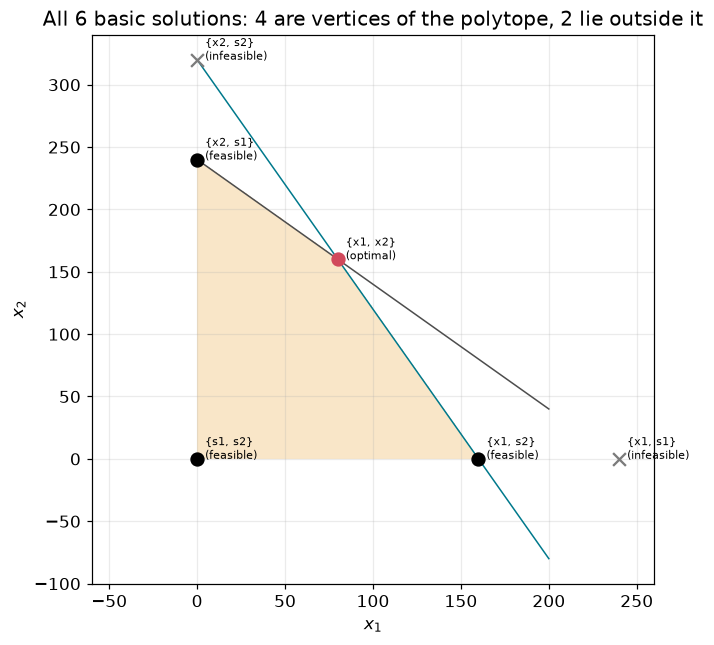

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.contourf(X1, X2, feasible.astype(float), levels=[0.5, 1], colors=[COLORS["accent"]], alpha=0.3)
ax.plot(x1g, labour_line, color=COLORS["boundary"], lw=1)
ax.plot(x1g, land_line, color="0.3", lw=1)

for _, row in df_farmer.iterrows():
    x1v, x2v = row.x[0], row.x[1]
    color = COLORS["optimum"] if row.feasible and np.isclose(row.objective, best.objective) else \
            ("black" if row.feasible else COLORS["infeasible"])
    marker = "o" if row.feasible else "x"
    ax.scatter(x1v, x2v, color=color, marker=marker, s=70, zorder=5)
    tag = "optimal" if np.isclose(row.objective, best.objective) and row.feasible else \
          ("feasible" if row.feasible else "infeasible")
    ax.annotate(f"  {{{row.basis}}}\n  ({tag})", (x1v, x2v), fontsize=7)

ax.set(xlim=(-60, 260), ylim=(-100, 340), xlabel="$x_1$", ylabel="$x_2$",
       title="All 6 basic solutions: 4 are vertices of the polytope, 2 lie outside it")
plt.tight_layout()
plt.show()

---
## 5. Why not just enumerate? The combinatorial explosion

Checking every basic solution works when $M=\binom{n}{m}$ is small - but it grows explosively. This is exactly why the simplex method (next notebook) exists: it "jumps" from one basic feasible solution to a better one instead of checking all of them.

n=   10, m=   5:  M = 252
n=   10, m=   9:  M = 10
n=  100, m=  50:  M = 1.0089e+29
n=  100, m=  90:  M = 1.7310e+13
n= 1000, m= 900:  M = 6.3851e+139


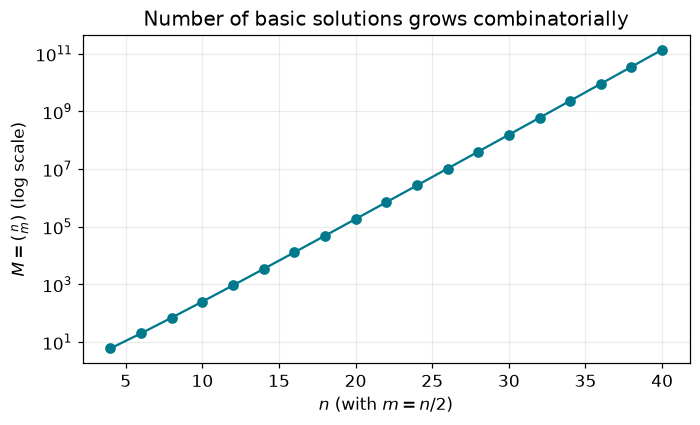

In [11]:
cases = [(10, 5), (10, 9), (100, 50), (100, 90), (1000, 900)]
for n, m in cases:
    try:
        M = comb(n, m)
        print(f"n={n:5d}, m={m:4d}:  M = {M:.4e}" if M > 1e6 else f"n={n:5d}, m={m:4d}:  M = {M}")
    except OverflowError:
        print(f"n={n:5d}, m={m:4d}:  M = (overflow)")

ns = np.arange(4, 41, 2)
Ms = [comb(n, n//2) for n in ns]
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.semilogy(ns, Ms, marker="o", color=COLORS["boundary"])
ax.set(xlabel="$n$ (with $m=n/2$)", ylabel="$M=\\binom{n}{m}$ (log scale)",
       title="Number of basic solutions grows combinatorially")
plt.tight_layout()
plt.show()

---
## Takeaways

1. Converting a max problem to standard min form, and inequalities to equalities via slack/surplus variables, does not change the optimum - only the representation.
2. A basic solution fixes $n-m$ variables at zero and solves for the rest; it is *feasible* only if the solved-for values are all $\ge0$.
3. For the farmer's problem, all 6 possible bases can be enumerated by hand (or in a few lines of code); the optimal *basic feasible* solution matches the graphical answer exactly: $(x_1,x_2)=(80,160)$, $f=-8000$.
4. Basic feasible solutions are exactly the vertices ("extreme points") of the feasible polytope - this is why the simplex method only ever needs to visit vertices.
5. $M=\binom{n}{m}$ grows too fast to enumerate for realistically-sized problems - motivating a smarter search. See `L07_simplex_method.ipynb`.

## Optional exercises

1. Add a third crop to the farmer's problem (a new column in $\mathbf A$ and a new profit coefficient). How many basic solutions are there now, and how many are feasible?
2. Modify `enumerate_basic_solutions` to also report, for each feasible basis, which original inequality constraints are binding (hint: compare slack/surplus values to zero).
3. For $n=1000,\,m=900$, roughly how long would it take a computer that evaluates $10^9$ bases per second to check them all? Compare that to how many *iterations* the simplex method typically needs (a small multiple of $m$).